# Chl Band Ratios

In [1]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting as oc_plotting
from ocpy.chl import band_ratios

from bing.models import anw as bing_anw
from bing.models import bbnw as bing_bbnw
from bing import inference as bing_inf
from bing import rt as bing_rt
from bing import chisq_fit

import anly_utils

In [2]:
#%matplotlib ipympl

# Load

## L23

In [3]:
ds = loisel23.load_ds(4,0)

### Unpack

In [4]:
l23_wave = ds.Lambda.data
l23_Rrs = ds.Rrs.data
a = ds.a.data
bb = ds.bb.data
adg = ds.ag.data + ds.ad.data
ag = ds.ag.data
ad = ds.ad.data
aph = ds.aph.data
anw = ds.anw.data

In [11]:
i490 = np.argmin(np.abs(l23_wave-490))
i555 = np.argmin(np.abs(l23_wave-555))

# Calculate Chl both ways

## Chl from a_ph

In [5]:
i440 = np.argmin(np.abs(l23_wave-440.))
Chla = aph[:,i440] / 0.05582
Chla.min(), Chla.max()

(np.float32(0.015263347), np.float32(8.445539))

## Band ratios

In [20]:
reload(band_ratios)
Chl_OC2 = []
Chl_OC4 = []
for ss in range(l23_Rrs.shape[0]):
    C4 = band_ratios.oc4(l23_wave, l23_Rrs[ss])
    C2 = band_ratios.oc2(l23_wave, l23_Rrs[ss])
    #
    Chl_OC2.append(C2)
    Chl_OC4.append(C4)

# Compare

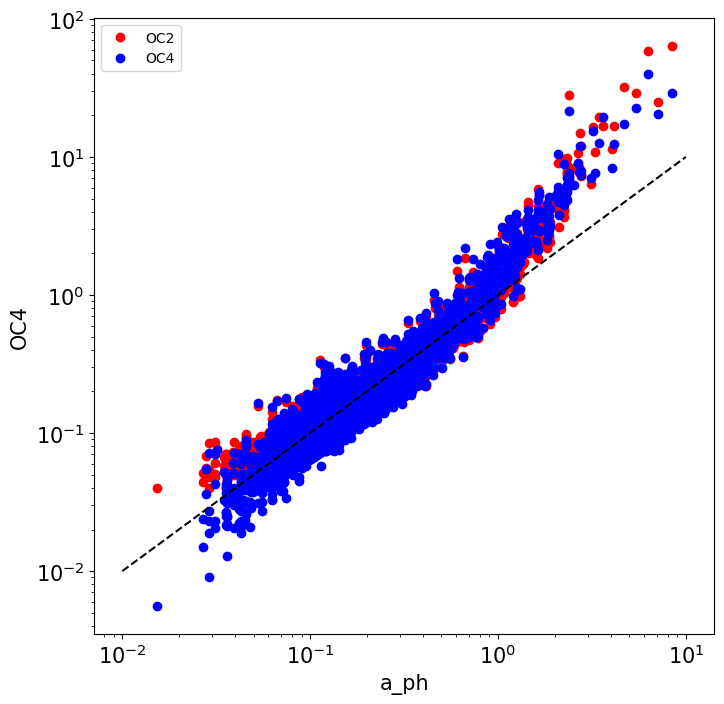

In [21]:
#
fig = plt.figure(figsize=(8,8))
ax = plt.gca()
#
ax.plot(Chla, Chl_OC2, 'ro', label='OC2')
ax.plot(Chla, Chl_OC4, 'bo', label='OC4')
# 1-1 line
ax.plot([0.01, 10.], [0.01, 10.], 'k--')
#
ax.set_xlabel('a_ph')
ax.set_ylabel('OC4')
# Log
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend()
oc_plotting.set_fontsize(ax, 15.)
#ax.set_xlim(400., None)
#
plt.show()

# Band ratio

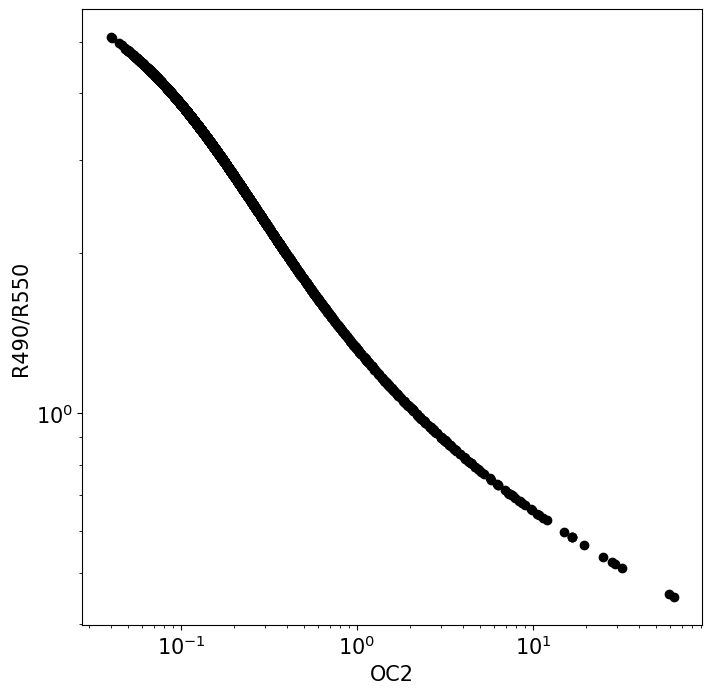

In [19]:
fig = plt.figure(figsize=(8,8))
ax = plt.gca()
#
ax.plot(Chl_OC2, l23_Rrs[:,i490]/l23_Rrs[:,i555], 'ko', label='OC2')
#ax.plot(Chla, Chl_OC4, 'bo', label='OC4')
# 1-1 line
#ax.plot([0.01, 10.], [0.01, 10.], 'k--')
#
ax.set_ylabel('R490/R550')
ax.set_xlabel('OC2')
# Log
ax.set_xscale('log')
ax.set_yscale('log')

#ax.legend()
oc_plotting.set_fontsize(ax, 15.)
#ax.set_xlim(400., None)
#
plt.show()

In [15]:
R = l23_Rrs[:,i490]/l23_Rrs[:,i555]
R.max()

np.float32(5.1013246)